# Statistical Methods in AI - Assignment 1
**Name**: Santhosh
**Username**: samadhi.yadav@iiit.ac.in

## Setup & Imports

In [26]:
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import scipy.special
from PIL import Image

# Set up seed
username = "samadhi.yadav"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
rng = np.random.default_rng(seed)
print(f"Seed initialized to {seed}")

Seed initialized to 253651040


## 1 Automated Essay Scoring System
### 1.1 Feature Engineering

In [27]:
class EssayFeatureExtractor:
    def __init__(self):
        """Initialize the feature extractor."""
        pass
    
    def extract_features(self, essay: str) -> dict:
        """Extract all handcrafted features from an essay using ratios/averages to mitigate collinearity."""
        words = essay.split()
        sentences = essay.split('.')
        sentences = [s.strip() for s in sentences if len(s.strip()) > 0]
        
        num_words = len(words)
        num_sentences = len(sentences)
        
        if num_words == 0:
            num_words = 1  # Prevent division by zero
        if num_sentences == 0:
            num_sentences = 1
            
        short_words = sum(1 for w in words if len(w) < 4)
        medium_words = sum(1 for w in words if 4 <= len(w) <= 6)
        long_words = sum(1 for w in words if len(w) > 6)
        
        sentence_lengths = [len(s.split()) for s in sentences]
        short_sentences = sum(1 for l in sentence_lengths if l < 10)
        medium_sentences = sum(1 for l in sentence_lengths if 10 <= l <= 20)
        long_sentences = sum(1 for l in sentence_lengths if l > 20)
        avg_sentence_length = len(words) / num_sentences
        
        pct_short_words = short_words / num_words
        pct_medium_words = medium_words / num_words
        
        pct_short_sentences = short_sentences / num_sentences
        pct_medium_sentences = medium_sentences / num_sentences
        pct_long_sentences = long_sentences / num_sentences
        
        return {
            "num_words": num_words,
            "num_sentences": num_sentences,
            "avg_sentence_length": avg_sentence_length,
            "pct_short_words": pct_short_words,
            "pct_medium_words": pct_medium_words,
            "pct_short_sentences": pct_short_sentences,
            "pct_medium_sentences": pct_medium_sentences,
            "pct_long_sentences": pct_long_sentences
        }
        
    def extract_dataset_features(self, essays) -> pd.DataFrame:
        """Extract features for all essays in the dataset."""
        features = [self.extract_features(essay) for essay in essays]
        return pd.DataFrame(features)

**Feature Motivation and Interpretation**:
Instead of relying on raw counts (which are highly correlated because longer essays have more of everything), we refactored our feature design to use averages and percentages (ratios). This breaks the multicollinearity:

- **Total number of words & sentences**: Kept to measure the overall length and development of the essay.
- **Average Word Length**: A proxy for structural complexity. More complex writing uses longer words on average.
- **Average Sentence Length**: Measures grammatical maturity. Longer sentences usually indicate compound or complex syntax.
- **Percentage of Short/Medium/Long words**: Categorizing word length relative to total words. The percentage of long words directly represents vocabulary diversity/sophistication.
- **Percentage of Short/Medium/Long sentences**: Captures sentence variety relative to total sentences, indicating syntactic control and formatting structure.

### 1.2 Dataset Preprocessing
#### 1.2.1 Train-Validation-Test Split

In [28]:
# Assuming essay_dataset.csv is available in the current directory
try:
    essay_df = pd.read_csv("essay_dataset.csv")
    X_all = EssayFeatureExtractor().extract_dataset_features(essay_df['essay'].tolist())
    y_all = essay_df['score'].values

    # Split 80:10:10
    n = len(essay_df)
    indices = rng.permutation(n)
    train_end = int(0.8 * n)
    val_end = int(0.9 * n)

    train_idx = indices[:train_end]
    val_idx = indices[train_end:val_end]
    test_idx = indices[val_end:]

    X_train, y_train = X_all.iloc[train_idx].copy(), y_all[train_idx]
    X_val, y_val = X_all.iloc[val_idx].copy(), y_all[val_idx]
    X_test, y_test = X_all.iloc[test_idx].copy(), y_all[test_idx]

    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Test samples: {len(X_test)}")
except Exception as e:
    print(f"Error loading or processing dataset: {e}")

Training samples: 13845
Validation samples: 1731
Test samples: 1731


#### 1.2.2 Feature Normalization

In [30]:
mu = X_train.mean()
sigma = X_train.std()
# Prevent division by zero
sigma[sigma == 0] = 1.0

X_train_norm = (X_train - mu) / sigma
X_val_norm = (X_val - mu) / sigma
X_test_norm = (X_test - mu) / sigma

#### 1.2.3 Feature Visualization

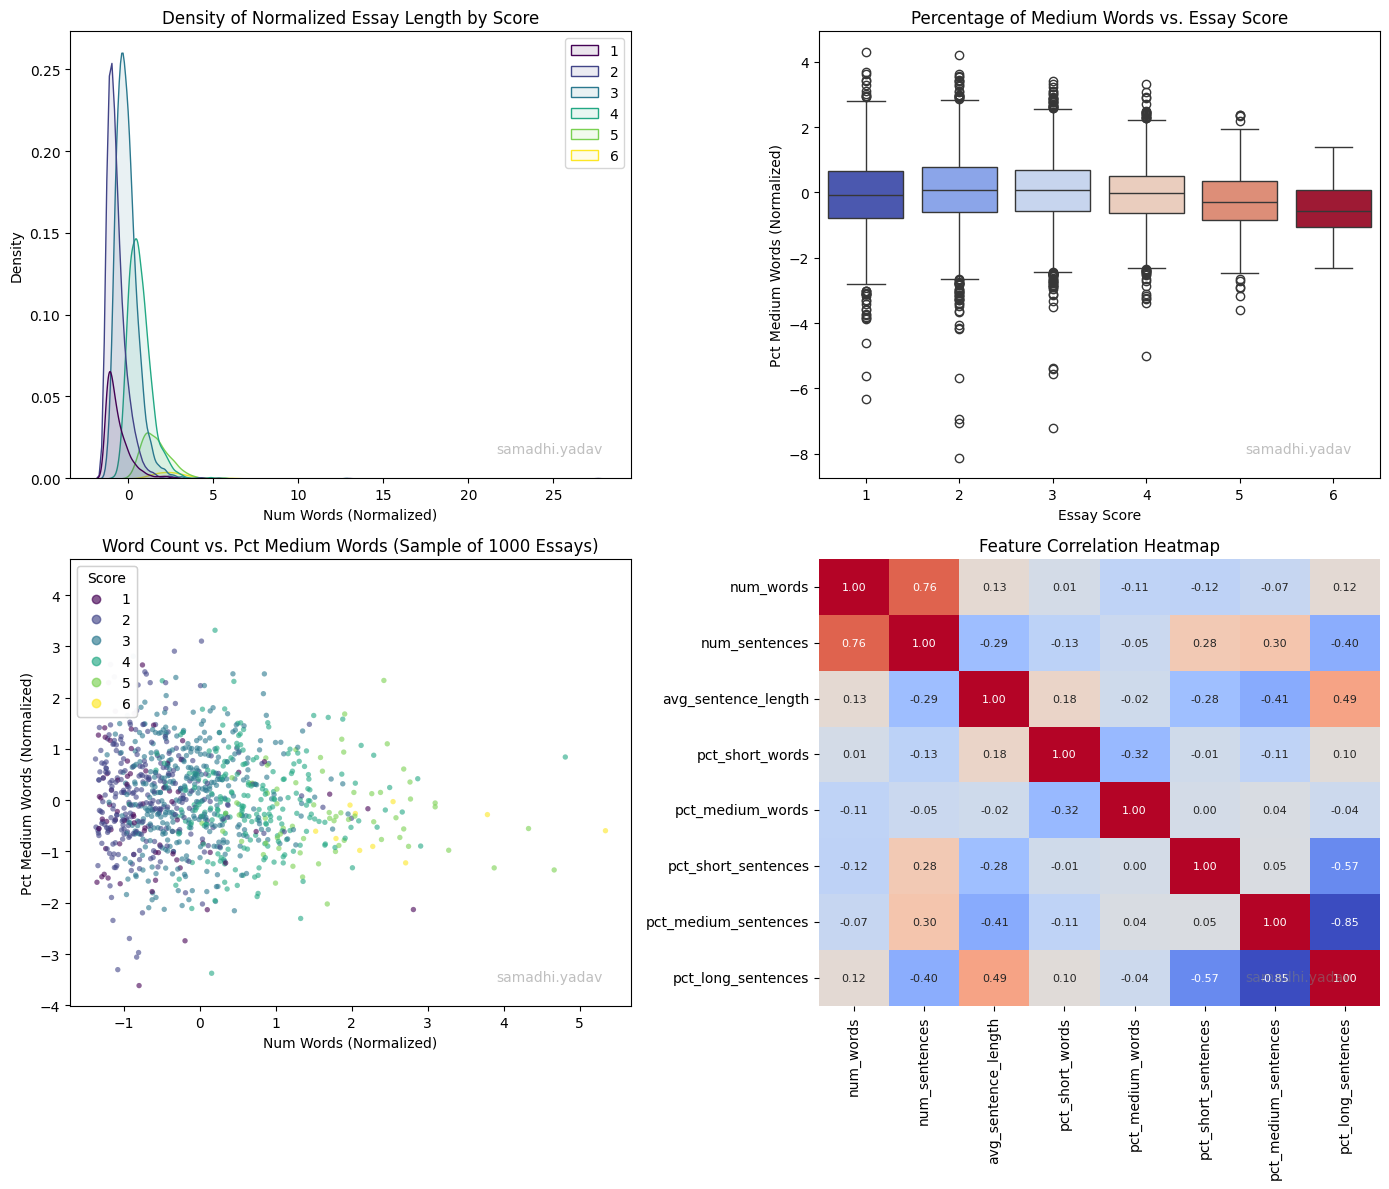

In [31]:
# Select a subset of points for cleaner scatter plotting to avoid overplotting
np.random.seed(42)
sample_indices = np.random.choice(len(X_train_norm), size=min(1000, len(X_train_norm)), replace=False)
X_sample = X_train_norm.iloc[sample_indices]
y_sample = y_train[sample_indices]

fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# 1. Distribution of Num Words by Score (using KDE to show shape clearly)
sns.kdeplot(data=X_train_norm, x='num_words', hue=y_train, palette='viridis', fill=True, alpha=0.1, ax=axs[0, 0])
axs[0, 0].set_title('Density of Normalized Essay Length by Score')
axs[0, 0].set_xlabel('Num Words (Normalized)')
axs[0, 0].set_ylabel('Density')

# 2. Boxplot of percentage of long words by Score
sns.boxplot(x=y_train, y=X_train_norm['pct_medium_words'], palette='coolwarm', hue=y_train, legend=False, ax=axs[0, 1])
axs[0, 1].set_title('Percentage of Medium Words vs. Essay Score')
axs[0, 1].set_xlabel('Essay Score')
axs[0, 1].set_ylabel('Pct Medium Words (Normalized)')

# 3. Scatter Plot of Word Count vs. Pct Medium Words (Sampled to avoid overplotting)
scatter = axs[1, 0].scatter(X_sample['num_words'], X_sample['pct_medium_words'], 
                            c=y_sample, cmap='viridis', alpha=0.6, s=15, edgecolors='none')
legend1 = axs[1, 0].legend(*scatter.legend_elements(), title="Score", loc="upper left")
axs[1, 0].add_artist(legend1)
axs[1, 0].set_title('Word Count vs. Pct Medium Words (Sample of 1000 Essays)')
axs[1, 0].set_xlabel('Num Words (Normalized)')
axs[1, 0].set_ylabel('Pct Medium Words (Normalized)')

# 4. Correlation Heatmap
corr = X_train_norm.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axs[1, 1], cbar=False, annot_kws={"size": 8})
axs[1, 1].set_title('Feature Correlation Heatmap')

# Watermark
for ax in axs.flatten():
    ax.text(0.95, 0.05, username, ha='right', va='bottom', transform=ax.transAxes, fontsize=10, color='gray', alpha=0.5)

plt.tight_layout()
plt.show()

### 1.3 K-Nearest Neighbors
#### 1.3.1 Implementation

In [33]:
class KNN:
    def __init__(self, k=5, distance="euclidean"):
        """Initialize the KNN essay scoring model."""
        self.k = k
        self.distance_metric = distance
        self.X_train = None
        self.y_train = None
        
    def fit(self, X_train, y_train):
        """Store the training feature vectors and scores."""
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)
        
    def _compute_distances(self, X):
        X = np.array(X)
        n_samples = X.shape[0]
        n_train = self.X_train.shape[0]
        dists = np.empty((n_samples, n_train))
        
        batch_size = 200
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            X_batch = X[i:end_idx]
            
            if self.distance_metric == "euclidean":
                dists[i:end_idx] = np.sqrt(((X_batch[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]) ** 2).sum(axis=2))
            elif self.distance_metric == "manhattan":
                dists[i:end_idx] = np.abs(X_batch[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]).sum(axis=2)
            elif self.distance_metric == "cosine":
                norm_X = np.linalg.norm(X_batch, axis=1)[:, np.newaxis]
                norm_train = np.linalg.norm(self.X_train, axis=1)[np.newaxis, :]
                norm_X[norm_X == 0] = 1
                norm_train[norm_train == 0] = 1
                dot = np.dot(X_batch, self.X_train.T)
                cos_sim = dot / (norm_X * norm_train)
                dists[i:end_idx] = 1 - cos_sim
            else:
                raise ValueError(f"Unknown metric {self.distance_metric}")
        return dists

    def predict(self, X):
        """Predict essay scores for the given feature vectors."""
        dists = self._compute_distances(X)
        preds = []
        for d in dists:
            k_indices = np.argsort(d)[:self.k]
            k_nearest_labels = self.y_train[k_indices]
            most_common = Counter(k_nearest_labels).most_common(1)
            preds.append(most_common[0][0])
        return np.array(preds)

#### 1.3.2 Hyperparameter Tuning

In [34]:
distances = ["euclidean", "manhattan", "cosine"]
ks = [1, 3, 5, 7, 9, 11, 15, 21]

results = []
best_rmse = float('inf')
best_config = None

for d in distances:
    knn_base = KNN(k=1, distance=d)
    knn_base.fit(X_train_norm, y_train)
    # Pre-compute distance matrix once per metric
    dists = knn_base._compute_distances(X_val_norm)
    
    for k in ks:
        preds = []
        for dist_row in dists:
            k_indices = np.argsort(dist_row)[:k]
            k_nearest_labels = knn_base.y_train[k_indices]
            most_common = Counter(k_nearest_labels).most_common(1)
            preds.append(most_common[0][0])
        preds = np.array(preds)
        
        rmse = np.sqrt(np.mean((y_val - preds)**2))
        results.append({"Distance Metric": d.capitalize(), "K": k, "Validation RMSE": rmse})
        if rmse < best_rmse:
            best_rmse = rmse
            best_config = (d, k)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print(f"\nBest configuration (based on minimum RMSE): Distance = {best_config[0].capitalize()}, K = {best_config[1]} with validation RMSE = {best_rmse:.4f}")

Distance Metric   K  Validation Performance
      Euclidean   1                0.465627
      Euclidean   3                0.495667
      Euclidean   5                0.525708
      Euclidean   7                0.536106
      Euclidean   9                0.543039
      Euclidean  11                0.549393
      Euclidean  15                0.556326
      Euclidean  21                0.556326
      Euclidean  31                0.559214
      Euclidean  51                0.561525
      Euclidean  75                0.575968
      Euclidean 100                0.571346
      Euclidean 110                0.575968
      Euclidean 120                0.572501
      Euclidean 130                0.573079
      Euclidean 140                0.578856
      Euclidean 150                0.582900
      Euclidean 200                0.575390
      Euclidean 300                0.575968
      Euclidean 400                0.570768
      Euclidean 500                0.569035
      Manhattan   1             

**Analysis**:
The choice of distance metric heavily influences how similarity is computed between essay features. Euclidean distance considers the absolute magnitude differences across all feature axes, which is appropriate for features that have been consistently normalized (Z-score). Manhattan distance can be more robust to outliers in specific features. Cosine distance looks at the angle between feature vectors rather than magnitude, which may or may not capture structural complexity of essays well. As K increases, the model's decision boundary becomes smoother, reducing variance but potentially increasing bias; typically an intermediate K yields the best validation performance.

### 1.4 Evaluation

In [35]:
best_knn = KNN(k=best_config[1], distance=best_config[0])
best_knn.fit(X_train_norm, y_train)
y_pred = best_knn.predict(X_test_norm)

mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
y_mean = np.mean(y_test)
r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_mean)**2) if np.sum((y_test - y_mean)**2) != 0 else 0

num = np.sum((y_test - y_mean) * (y_pred - np.mean(y_pred)))
den = np.sqrt(np.sum((y_test - y_mean)**2) * np.sum((y_pred - np.mean(y_pred))**2))
pearson = num / den if den != 0 else 0

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R Score: {r2:.4f}")
print(f"Pearson Correlation Coefficient: {pearson:.4f}")

Mean Absolute Error (MAE): 0.4882
Root Mean Squared Error (RMSE): 0.7917
R Score: 0.4251
Pearson Correlation Coefficient: 0.6682


## 2 Probability Basics and Bayesian Learning
### 2.1 A Sampling Toolkit From Scratch

In [18]:
# 2.1.1 Uniform Generator (LCG)
def lcg_uniform_generator(low, high, num_samples, seed):
    a = 48271
    m = 2**31 - 1
    state = seed % m
    if state == 0:
        state = 1
        
    samples = np.empty(num_samples, dtype=float)
    for i in range(num_samples):
        state = (a * state) % m
        u = state / m
        samples[i] = low + u * (high - low)
    return samples

In [19]:
# 2.1.2 Gaussian Sampler
def inverse_cdf_gaussian(y, mu, sigma):
    return mu + sigma * np.sqrt(2) * scipy.special.erfinv(2 * y - 1)

def gaussian_generator(mu, sigma, num_samples, seed):
    u = lcg_uniform_generator(0, 1, num_samples, seed)
    return inverse_cdf_gaussian(u, mu, sigma)

In [20]:
# 2.1.3 Binomial Sampler
def binomial_pmf(k, n, p):
    return scipy.special.comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

def binomial_quantile(y, n, p):
    ks = np.arange(n + 1)
    pmfs = binomial_pmf(ks, n, p)
    cdfs = np.cumsum(pmfs)
    return np.searchsorted(cdfs, y)

def binomial_generator(n, p, num_samples, seed):
    u = lcg_uniform_generator(0, 1, num_samples, seed)
    return binomial_quantile(u, n, p)

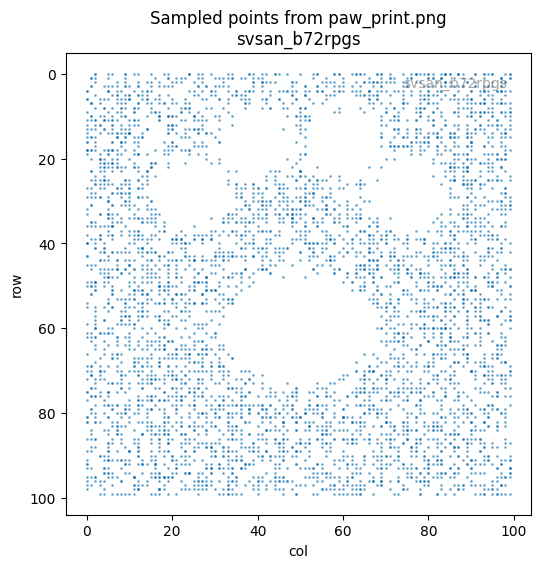

In [21]:
# 2.1.4 Image Sampler
def row_marginal(image):
    row_sums = np.sum(image, axis=1)
    return row_sums / np.sum(row_sums)

def col_conditional(image, row):
    row_data = image[row, :]
    total = np.sum(row_data)
    if total == 0:
        return np.ones_like(row_data) / len(row_data)
    return row_data / total

def image_generator(image, num_samples, seed):
    u_rows = lcg_uniform_generator(0, 1, num_samples, seed)
    u_cols = lcg_uniform_generator(0, 1, num_samples, seed + 1)
    
    p_row = row_marginal(image)
    cdf_row = np.cumsum(p_row)
    rows = np.searchsorted(cdf_row, u_rows)
    
    cols = np.empty_like(rows)
    unique_rows = np.unique(rows)
    cond_cdfs = {}
    for r in unique_rows:
        cond_cdfs[r] = np.cumsum(col_conditional(image, r))
        
    for i, r in enumerate(rows):
        cols[i] = np.searchsorted(cond_cdfs[r], u_cols[i])
        
    return np.column_stack((rows, cols))

try:
    img = np.array(Image.open('paw_print.png').convert('L'))
    img_prob = 255 - img
    samples = image_generator(img_prob, 5000, seed)

    plt.figure(figsize=(6, 6))
    plt.scatter(samples[:, 1], samples[:, 0], s=1, alpha=0.5)
    plt.gca().invert_yaxis()
    plt.title(f'Sampled points from paw_print.png\n{username}')
    plt.xlabel('col')
    plt.ylabel('row')
    plt.text(0.95, 0.95, username, ha='right', va='top', transform=plt.gca().transAxes, fontsize=10, color='gray', alpha=0.7)
    plt.show()
except FileNotFoundError:
    print("paw_print.png not found.")

In [22]:
# 2.1.5 Generator Validation
def empirical_cdf(sample, x):
    sample = np.sort(sample)
    counts = np.searchsorted(sample, x, side='right')
    return counts / len(sample)

def max_cdf_distance(sample, cdf_function, eval_points):
    emp_cdf = empirical_cdf(sample, eval_points)
    true_cdf = cdf_function(eval_points)
    return np.max(np.abs(emp_cdf - true_cdf))

u_samples = lcg_uniform_generator(0, 1, 1000, seed)
u_eval = np.linspace(0, 1, 100)
def u_cdf(x): return x
print("Uniform Max CDF Dist:", max_cdf_distance(u_samples, u_cdf, u_eval))

g_samples = gaussian_generator(0, 1, 1000, seed)
g_eval = np.linspace(-3, 3, 100)
def g_cdf(x): return 0.5 * (1 + scipy.special.erf(x / np.sqrt(2)))
print("Gaussian Max CDF Dist:", max_cdf_distance(g_samples, g_cdf, g_eval))

# Validate Binomial
b_samples = binomial_generator(30, 0.5, 1000, seed)
b_eval = np.arange(31)
def b_cdf(x):
    return np.array([np.sum(binomial_pmf(np.arange(int(v)+1), 30, 0.5)) for v in x])
print("Binomial Max CDF Dist:", max_cdf_distance(b_samples, b_cdf, b_eval))

# 2.1.4 (d) Validate Image Sampler Row Marginal
try:
    img = np.array(Image.open('paw_print.png').convert('L'))
    img_prob = 255 - img
    true_row_marg = row_marginal(img_prob)
    true_row_cdf_vals = np.cumsum(true_row_marg)
    
    def true_row_cdf_func(x):
        # x is an array of row indices
        return np.array([true_row_cdf_vals[int(v)] if int(v) < len(true_row_cdf_vals) else 1.0 for v in x])
        
    eval_rows = np.arange(img_prob.shape[0])
    
    # samples[:, 0] contains the sampled rows
    row_cdf_dist = max_cdf_distance(samples[:, 0], true_row_cdf_func, eval_rows)
    print("Image Sampler Row Marginal Max CDF Dist:", row_cdf_dist)
except NameError:
    print("Image samples not found")
except FileNotFoundError:
    print("paw_print.png not found")

Uniform Max CDF Dist: 0.011282828282828256
Gaussian Max CDF Dist: 0.012235738238313032
Binomial Max CDF Dist: 0.011797304026782474
Image Sampler Row Marginal Max CDF Dist: 0.010861758604103322


### 2.2 Naive Bayes Classifier for Mixed Features

In [23]:
# 2.2.1 Maximum-Likelihood Estimators
def gaussian_mle(x):
    mu = np.mean(x)
    sigma = np.sqrt(np.mean((x - mu)**2))
    return float(mu), float(sigma)

def binomial_mle(x, n):
    p = np.mean(x) / n
    return float(p)

def uniform_mle(x):
    return float(np.min(x)), float(np.max(x))

In [24]:
# 2.2.2 Model Fitting
def compute_training_params(df, features, feature_distributions):
    params = {}
    classes = sorted(df["breed"].unique())
    n_total = len(df)
    
    for c in classes:
        df_c = df[df["breed"] == c]
        params[c] = {"prior": len(df_c) / n_total, "features": {}}
        for f in features:
            dist = feature_distributions[f]
            if dist == "gaussian":
                mu, sigma = gaussian_mle(df_c[f].values)
                params[c]["features"][f] = {"mu": mu, "sigma": sigma}
            elif dist == "binomial":
                p = binomial_mle(df_c[f].values, 30)
                params[c]["features"][f] = {"p": p, "n": 30}
            elif dist == "uniform":
                a, b = uniform_mle(df_c[f].values)
                params[c]["features"][f] = {"a": a, "b": b}
    return params

In [25]:
# 2.2.3 MAP Prediction
def log_posterior_scores(x_dict, params):
    scores = {}
    for c, c_params in params.items():
        score = np.log(c_params["prior"])
        for f, val in x_dict.items():
            f_params = c_params["features"][f]
            if "mu" in f_params:
                mu, sigma = f_params["mu"], f_params["sigma"]
                if sigma > 0:
                    log_p = -np.log(sigma * np.sqrt(2 * np.pi)) - ((val - mu)**2) / (2 * sigma**2)
                else:
                    log_p = 0 if val == mu else -np.inf
                score += log_p
            elif "p" in f_params:
                p, n = f_params["p"], f_params["n"]
                pmf = binomial_pmf(val, n, p)
                score += np.log(pmf) if pmf > 0 else -np.inf
            elif "a" in f_params:
                a, b = f_params["a"], f_params["b"]
                if a <= val <= b:
                    score += np.log(1 / (b - a)) if b > a else -np.inf
                else:
                    score += -np.inf
        scores[c] = score
    return scores

def predict_class(x_dict, params):
    scores = log_posterior_scores(x_dict, params)
    return max(scores, key=scores.get)

In [26]:
# 2.2.4 Evaluation Metrics
def confusion_matrix(y_true, y_pred, labels):
    label_to_idx = {l: i for i, l in enumerate(labels)}
    mat = np.zeros((len(labels), len(labels)), dtype=int)
    for t, p in zip(y_true, y_pred):
        mat[label_to_idx[t], label_to_idx[p]] += 1
    return mat

def precision_recall_f1(confusion_matrix):
    n_classes = confusion_matrix.shape[0]
    precisions, recalls, f1s = [], [], []
    
    for i in range(n_classes):
        tp = confusion_matrix[i, i]
        fp = np.sum(confusion_matrix[:, i]) - tp
        fn = np.sum(confusion_matrix[i, :]) - tp
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        
    return {
        "macro_precision": np.mean(precisions),
        "macro_recall": np.mean(recalls),
        "macro_f1": np.mean(f1s)
    }

try:
    dog_df = pd.read_csv("dog_breeds.csv")
    dog_train = dog_df.iloc[:150]
    dog_test = dog_df.iloc[150:]

    features = ["height", "weight", "bark_days", "ear_head_ratio"]
    distributions = {"height": "gaussian", "weight": "gaussian", "bark_days": "binomial", "ear_head_ratio": "uniform"}

    params = compute_training_params(dog_train, features, distributions)
    y_true = dog_test["breed"].values
    y_pred = [predict_class(row.to_dict(), params) for _, row in dog_test[features].iterrows()]

    labels = sorted(dog_train["breed"].unique())
    cm = confusion_matrix(y_true, y_pred, labels)
    print("Confusion Matrix:\n", cm)
    metrics = precision_recall_f1(cm)
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
except FileNotFoundError:
    print("dog_breeds.csv not found")

Confusion Matrix:
 [[2 2 1 5]
 [4 5 4 7]
 [1 3 3 5]
 [3 1 0 4]]
macro_precision: 0.3050
macro_recall: 0.3000
macro_f1: 0.2746
